# MicroLive: Batch Processing via Command Line

This notebook demonstrates how to use MicroLive programmatically for batch processing of microscopy images. The workflow mirrors the steps available in the GUI but enables automated analysis of multiple datasets.

**Pipeline Overview:**
- Import libraries and configure paths
- Load microscopy images (TIFF or LIF)
- Photobleaching correction
- Cell segmentation (Watershed)
- Particle tracking and spot detection
- Mean Square Displacement (MSD) analysis
- Intensity and SNR analysis
- Export results

## Import Libraries

Import MicroLive's `microscopy` module and other necessary packages.

In [1]:
"""
MicroLive Notebook
==================
This notebook requires MicroLive to be installed:
    pip install microlive

For development mode:
    pip install -e /path/to/microlive
"""
# MicroLive imports
from microlive import microscopy as mi
from microlive.utils.device import check_gpu_status

# Verify GPU support
check_gpu_status()

# Standard scientific imports
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path


PyTorch version: 2.10.0.dev20251205
✅ MPS available: Apple Silicon GPU (MPS)


## Load Microscopy Image

MicroLive supports TIFF and LIF file formats. Images must be in 5D format `[T, Z, Y, X, C]` (MicroLive's internal format).

**Common TIFF axis orders:**
- **TCZYX**: ImageJ/OME-TIFF standard (most common for exported files)
- **TZYXC**: MicroLive internal format
- **ZCYX**: Single time point, Z-stack

Use MicroLive's `ConvertFormat` class to convert between formats.

In [2]:
# Define path to your image file
image_path = Path("/Users/nzlab-la/Desktop/Github/virtual_cell/spatio_temporal_models/results_simulation/simulated_microscopy.tif")
# For TIFF files:
if image_path.suffix.lower() in ['.tif', '.tiff']:
    raw_image = tifffile.imread(str(image_path))
    print(f"Loaded TIFF with shape: {raw_image.shape}")
    
    # IMPORTANT: Specify the axis order of YOUR file
    # Most common formats:
    #   - TCZYX: ImageJ/OME-TIFF standard (e.g., shape (360, 4, 10, 512, 512) = T=360, C=4, Z=10, Y=512, X=512)
    #   - TZYXC: MicroLive internal format
    #   - ZCYX: Single time point with Z-stack
    
    # Set the axis order that matches YOUR file
    input_axis_order = ['T', 'C', 'Z', 'Y', 'X']  # Example: TCZYX format
    
    # Convert to MicroLive's standard format [T, Z, Y, X, C]
    converter = mi.ConvertFormat(
        image=raw_image,
        original_order=input_axis_order,
        desired_order=['T', 'Z', 'Y', 'X', 'C']
    )
    image_stack = converter.convert()
    print(f"Converted to MicroLive format [T, Z, Y, X, C]: {image_stack.shape}")
    
# For LIF files (already returns TZYXC format):
elif image_path.suffix.lower() == '.lif':
    lif_reader = mi.ReadLif(path=str(image_path), show_metadata=True, format='TZYXC')
    list_images, list_names, pixel_xy_um, voxel_z_um, channel_names, num_channels, list_time_intervals, bit_depth, _, _, _ = lif_reader.read()
    
    # Select the first image in the LIF file
    selected_image_index = 0
    image_stack = list_images[selected_image_index]
    print(f"Loaded LIF scene '{list_names[selected_image_index]}' with shape: {image_stack.shape}")

print(f"\nFinal image shape [T, Z, Y, X, C]: {image_stack.shape}")

Loaded TIFF with shape: (360, 4, 10, 512, 512)
Converted to MicroLive format [T, Z, Y, X, C]: (360, 10, 512, 512, 4)

Final image shape [T, Z, Y, X, C]: (360, 10, 512, 512, 4)


## Define Image Metadata

Define the physical parameters of your microscopy image. These are essential for accurate quantitative analysis.

In [3]:
# Physical parameters (adjust to your microscope settings)
pixel_size_xy_nm = 130  # Pixel size in nanometers (XY)
voxel_size_z_nm = 500   # Voxel size in nanometers (Z)
time_interval_sec = 1.0  # Time between frames in seconds

# For MicroLive classes
list_voxels = [voxel_size_z_nm, pixel_size_xy_nm]  # [Z, YX]

# Extract dimensions from the correctly formatted image
n_timepoints = image_stack.shape[0]
n_zslices = image_stack.shape[1]
height_y = image_stack.shape[2]
width_x = image_stack.shape[3]
n_channels = image_stack.shape[4]

print(f"Image dimensions (TZYXC format):")
print(f"  Time points (T): {n_timepoints}")
print(f"  Z-slices (Z): {n_zslices}")
print(f"  Height (Y): {height_y} px")
print(f"  Width (X): {width_x} px")
print(f"  Channels (C): {n_channels}")
print(f"\nPhysical scale:")
print(f"  Pixel size: {pixel_size_xy_nm} nm")
print(f"  Z-step: {voxel_size_z_nm} nm")
print(f"  Frame interval: {time_interval_sec} sec")

Image dimensions (TZYXC format):
  Time points (T): 360
  Z-slices (Z): 10
  Height (Y): 512 px
  Width (X): 512 px
  Channels (C): 4

Physical scale:
  Pixel size: 130 nm
  Z-step: 500 nm
  Frame interval: 1.0 sec


## Display Image

Visualize the first frame with maximum Z-projection for all color channels.

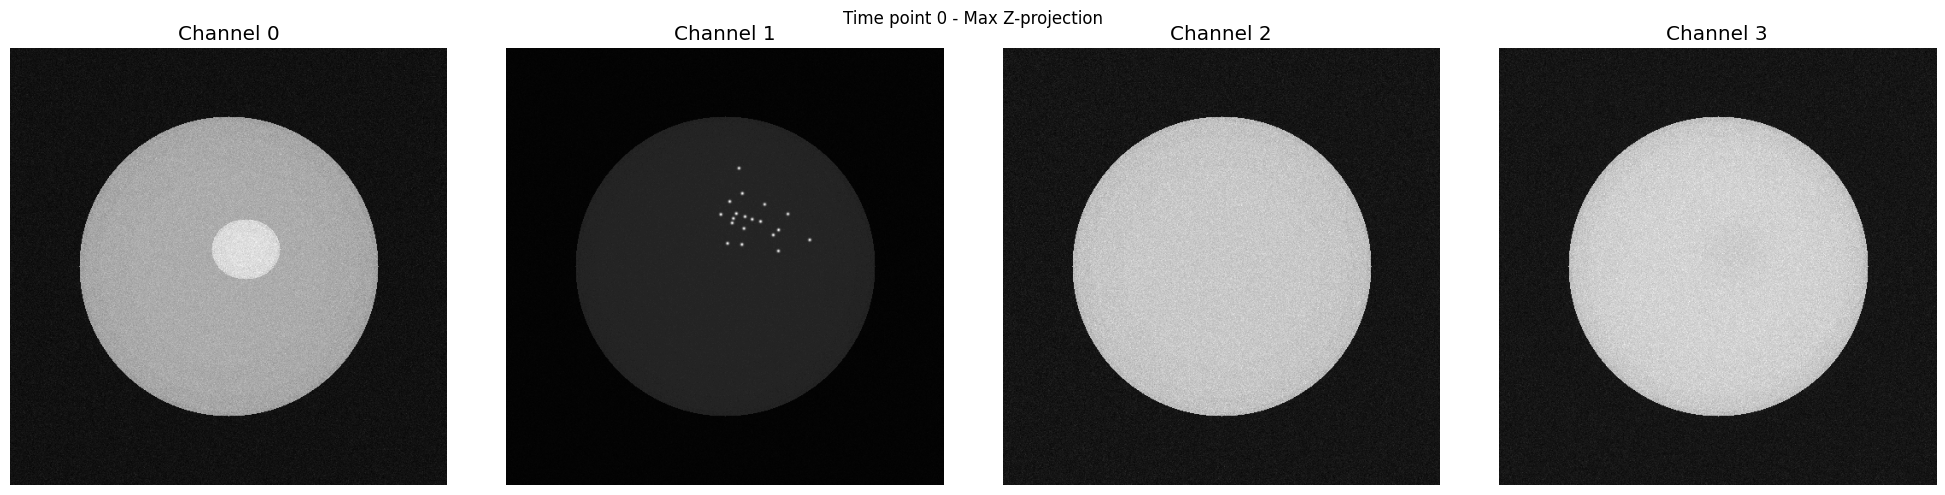

In [4]:
# Select time point
time_point = 0

# Maximum Z-projection
max_projection = np.max(image_stack[time_point], axis=0)  # Shape: [Y, X, C]

# Plot all channels
fig, axes = plt.subplots(1, n_channels, figsize=(5*n_channels, 5))
if n_channels == 1:
    axes = [axes]

for ch in range(n_channels):
    axes[ch].imshow(max_projection[:, :, ch], cmap='gray')
    axes[ch].set_title(f'Channel {ch}')
    axes[ch].axis('off')

plt.suptitle(f'Time point {time_point} - Max Z-projection')
plt.tight_layout()
plt.show()

## Photobleaching Correction

Correct for intensity decay over time due to photobleaching. MicroLive fits an exponential decay model and normalizes each frame to the initial intensity.

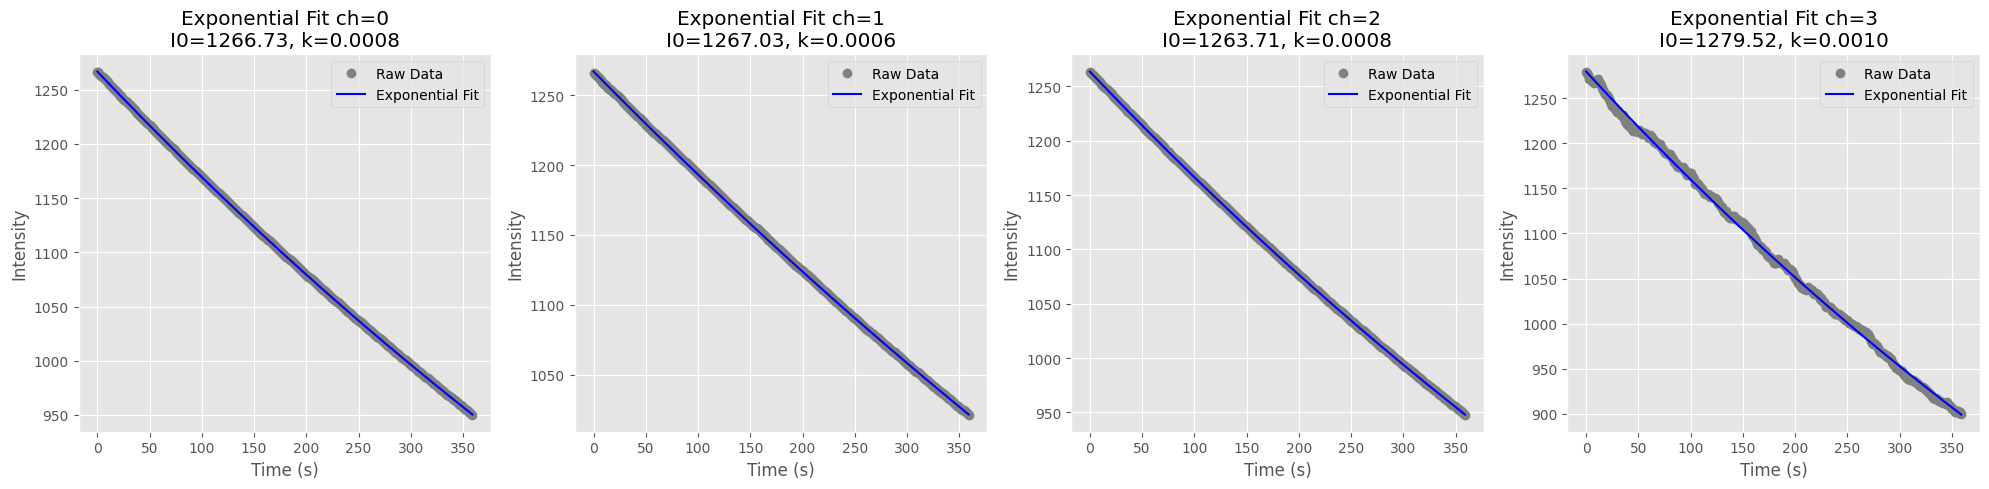


Decay rates per channel: [0.0008003698111663124, 1266.7287868123055, 0.0006005125313180681, 1267.030141744751, 0.0008003630759463975, 1263.705525785037, 0.0009822145384009039, 1279.5231293958673]


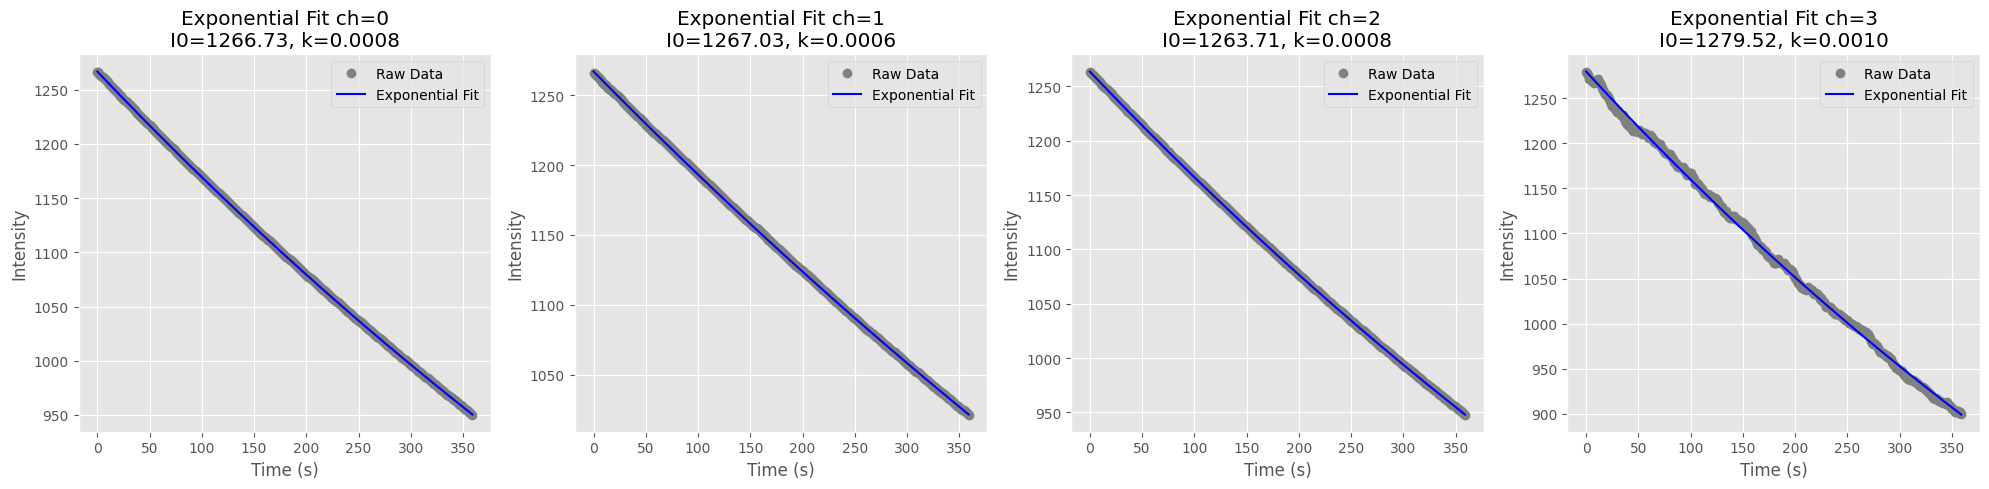

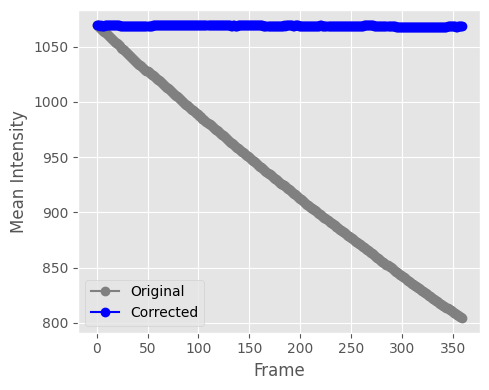

Corrected image shape: (360, 10, 512, 512, 4)


In [5]:
# Create a simple mask (entire image) or use segmentation mask
mask_YX = np.ones((height_y, width_x), dtype=bool)

# Calculate and apply photobleaching correction
photobleach = mi.Photobleaching(
    image_TZYXC=image_stack,
    mask_YX=mask_YX,
    show_plot=True,
    mode='inside_cell',
    time_interval_seconds=time_interval_sec
)

# Get decay rates for each channel
decay_rates = photobleach.calculate_photobleaching()
print(f"\nDecay rates per channel: {decay_rates}")

# Apply correction
image_corrected, _ = photobleach.apply_photobleaching_correction()
print(f"Corrected image shape: {image_corrected.shape}")

## Cell Segmentation

Segment cells using the Watershed algorithm. For Cellpose segmentation, the GUI provides additional functionality.

In [6]:
image_corrected[0].shape

(10, 512, 512, 4)

Running cytosol segmentation...
Cytosol: 1 cells detected
Running nucleus segmentation...
Nucleus: 1 nuclei detected
After synchronization: 1 cells, 1 nuclei


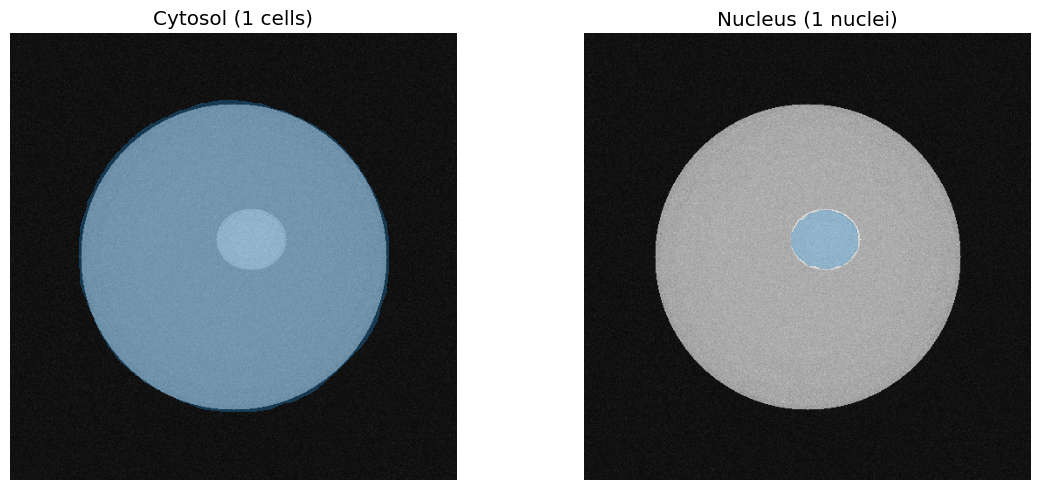

In [7]:
# Cellpose Segmentation - Matching GUI Behavior
# The GUI runs cytosol and nucleus segmentation as SEPARATE operations

# Channel and diameter settings
cytosol_channel = 0   # Channel index for cytosol segmentation
nucleus_channel = 0   # Channel index for nucleus segmentation (can be same or different)
diameter_cytosol = 300  # Average cytosol diameter in pixels
diameter_nucleus = 60   # Average nucleus diameter in pixels

# Get image for segmentation (first time point)
image_for_seg = image_corrected[0]  # Shape: [Z, Y, X, C]

# Step 1: Run Cytosol Segmentation (using cyto3 model)
print("Running cytosol segmentation...")
segmenter_cyto = mi.CellSegmentation(
    image_for_seg,
    channels_cytosol=[cytosol_channel],
    channels_nucleus=None,  # Only cytosol
    diameter_cytosol=diameter_cytosol,
    model_cyto_segmentation='cyto3',  # Default model for cytosol
    selection_metric=None,
    running_in_pipeline=True,
    show_plot=False
)
mask_cytosol, _, _ = segmenter_cyto.calculate_masks()
print(f"Cytosol: {np.max(mask_cytosol) if mask_cytosol is not None else 0} cells detected")

# Step 2: Run Nucleus Segmentation (using nuclei model)
print("Running nucleus segmentation...")
segmenter_nuc = mi.CellSegmentation(
    image_for_seg,
    channels_cytosol=None,  # Only nucleus
    channels_nucleus=[nucleus_channel],
    diameter_nucleus=diameter_nucleus,
    model_nuc_segmentation='nuclei',  # Default model for nucleus
    selection_metric=None,
    running_in_pipeline=True,
    show_plot=False
)
_, mask_nucleus, _ = segmenter_nuc.calculate_masks()
print(f"Nucleus: {np.max(mask_nucleus) if mask_nucleus is not None else 0} nuclei detected")

# Step 3: Synchronize masks (ensures consistent cell IDs between cytosol and nucleus)
if mask_cytosol is not None and mask_nucleus is not None:
    mask_cytosol, mask_nucleus = mi.CellSegmentation.synchronize_masks(mask_cytosol, mask_nucleus)
    print(f"After synchronization: {np.max(mask_cytosol)} cells, {np.max(mask_nucleus)} nuclei")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Create max projection for display
max_proj = np.max(image_for_seg, axis=0)[:, :, cytosol_channel]

# Left: Cytosol
axes[0].imshow(max_proj, cmap='gray')
if mask_cytosol is not None and np.max(mask_cytosol) > 0:
    cytosol_overlay = np.ma.masked_where(mask_cytosol == 0, mask_cytosol)
    axes[0].imshow(cytosol_overlay, cmap='tab10', alpha=0.4)
axes[0].set_title(f'Cytosol ({np.max(mask_cytosol) if mask_cytosol is not None else 0} cells)')
axes[0].axis('off')

# Right: Nucleus
axes[1].imshow(max_proj, cmap='gray')
if mask_nucleus is not None and np.max(mask_nucleus) > 0:
    nucleus_overlay = np.ma.masked_where(mask_nucleus == 0, mask_nucleus)
    axes[1].imshow(nucleus_overlay, cmap='tab10', alpha=0.4)
axes[1].set_title(f'Nucleus ({np.max(mask_nucleus) if mask_nucleus is not None else 0} nuclei)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## Particle Tracking

Detect and track fluorescent spots across frames. This step performs:
- Spot detection using local intensity thresholding
- Trajectory linking across frames
- Intensity calculation for each spot

In [8]:
# Tracking parameters
tracking_params = {
    'channels_spots': [1],           # Channel to detect spots in
    'channels_cytosol': [0],         # Cytosol channel for background
    'channels_nucleus': [None],      # Nucleus channel (None if not applicable)
    'threshold_for_spot_detection': 83,  # Detection threshold
    'yx_spot_size_in_px': 5,         # Expected spot size in pixels
    'z_spot_size_in_px': 2,          # Spot size in Z
    'cluster_radius_nm': 500,        # Cluster detection radius
    'min_length_trajectory': 20,     # Minimum trajectory length (frames)
    'maximum_range_search_pixels': 9,  # Max displacement between frames
    'memory': 1,                     # Frames to remember for linking
    'link_using_3d_coordinates': True,
    'use_maximum_projection': True,
}

# Create binary mask from labeled mask
binary_mask = (mask_cytosol > 0).astype(bool)

# Run particle tracking
tracker = mi.ParticleTracking(
    image=image_corrected,
    list_voxels=list_voxels,
    masks=binary_mask,
    step_size_in_sec=time_interval_sec,
    **tracking_params
)

# Get tracking results
list_dataframes, _ = tracker.run()

# Combine all dataframes
df_tracking = list_dataframes[0] if list_dataframes else pd.DataFrame()

print(f"\nTracking Results:")
print(f"  Total spots detected: {len(df_tracking)}")
print(f"  Unique trajectories: {df_tracking['particle'].nunique() if 'particle' in df_tracking.columns else 0}")

# Preview dataframe
if not df_tracking.empty:
    print("\nDataFrame columns:")
    print(df_tracking.columns.tolist())
    display(df_tracking.head())


Tracking Results:
  Total spots detected: 144655
  Unique trajectories: 4268

DataFrame columns:
['image_id', 'cell_id', 'nuc_loc_y', 'nuc_loc_x', 'cyto_loc_y', 'cyto_loc_x', 'nuc_area_px', 'cyto_area_px', 'cell_area_px', 'z', 'y', 'x', 'is_nuc', 'is_cluster', 'cluster_size', 'spot_type', 'is_cell_fragmented', 'nuc_int_ch_0', 'nuc_int_ch_1', 'nuc_int_ch_2', 'nuc_int_ch_3', 'cyto_int_ch_0', 'cyto_int_ch_1', 'cyto_int_ch_2', 'cyto_int_ch_3', 'complete_cell_int_ch_0', 'complete_cell_int_ch_1', 'complete_cell_int_ch_2', 'complete_cell_int_ch_3', 'pseudo_cyto_int_ch_0', 'pseudo_cyto_int_ch_1', 'pseudo_cyto_int_ch_2', 'pseudo_cyto_int_ch_3', 'nuc_cyto_int_ratio_ch_0', 'nuc_cyto_int_ratio_ch_1', 'nuc_cyto_int_ratio_ch_2', 'nuc_cyto_int_ratio_ch_3', 'nuc_pseudo_cyto_int_ratio_ch_0', 'nuc_pseudo_cyto_int_ratio_ch_1', 'nuc_pseudo_cyto_int_ratio_ch_2', 'nuc_pseudo_cyto_int_ratio_ch_3', 'spot_int_ch_0', 'spot_int_ch_1', 'spot_int_ch_2', 'spot_int_ch_3', 'psf_amplitude_ch_0', 'psf_amplitude_ch_1',

,image_id,cell_id,nuc_loc_y,nuc_loc_x,cyto_loc_y,cyto_loc_x,nuc_area_px,cyto_area_px,cell_area_px,z,...,total_spot_int_ch_1,total_spot_int_ch_2,total_spot_int_ch_3,spot_size_ch_0,spot_size_ch_1,spot_size_ch_2,spot_size_ch_3,frame,time,particle
0,0,0,0,0,255,256,0,100343,100343,0.0,...,80272.0,80527.0,82228.0,4.6333,4.4200,4.6753,4.6941,0,0.0,0
1,0,0,0,0,255,256,0,100343,100343,0.0,...,76586.0,76594.0,78205.0,4.6114,4.5853,4.6100,4.5782,0,0.0,1
2,0,0,0,0,255,256,0,100343,100343,0.0,...,80224.0,80053.0,81925.0,4.7657,4.7148,4.6863,4.8563,0,0.0,2
3,0,0,0,0,255,256,0,100343,100343,0.0,...,80414.0,80589.0,82417.0,4.7890,4.6084,4.8611,4.7577,0,0.0,3
4,0,0,0,0,255,256,0,100343,100343,0.0,...,74704.0,74476.0,76053.0,4.1751,4.1744,4.1765,4.1264,0,0.0,4


## Mean Square Displacement (MSD) Analysis

Calculate the MSD to determine diffusion coefficients from particle trajectories.

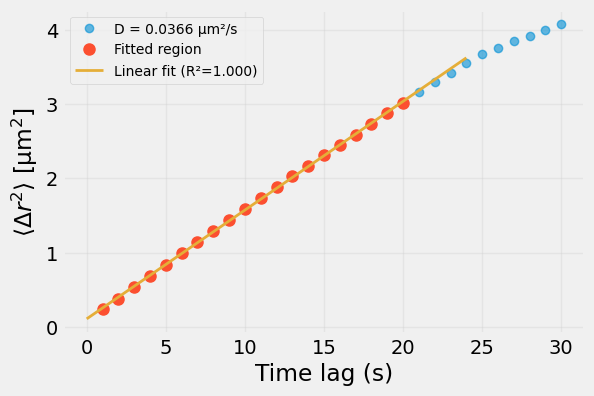


Diffusion coefficient: 0.0366 µm²/s


In [9]:
if not df_tracking.empty and 'particle' in df_tracking.columns:
    # MSD parameters
    microns_per_pixel = pixel_size_xy_nm / 1000  # Convert nm to µm
    max_lagtime = 30  # Maximum lag time in frames
    
    # Calculate MSD
    msd_analyzer = mi.ParticleMotion(
        trackpy_dataframe=df_tracking,
        microns_per_pixel=microns_per_pixel,
        step_size_in_sec=time_interval_sec,
        max_lagtime=max_lagtime,
        show_plot=True,
        is_3d=False,  # Set to True for 3D MSD
        max_fit_points=20
    )
    
    # Get diffusion coefficient
    diffusion_coeff, msd_data,  _, _, _, _ ,_= msd_analyzer.calculate_msd()
    print(f"\nDiffusion coefficient: {diffusion_coeff:.4f} µm²/s")
else:
    print("No tracking data available for MSD analysis.")

## Signal-to-Noise Ratio (SNR) Distribution

Analyze the SNR distribution for detected spots.

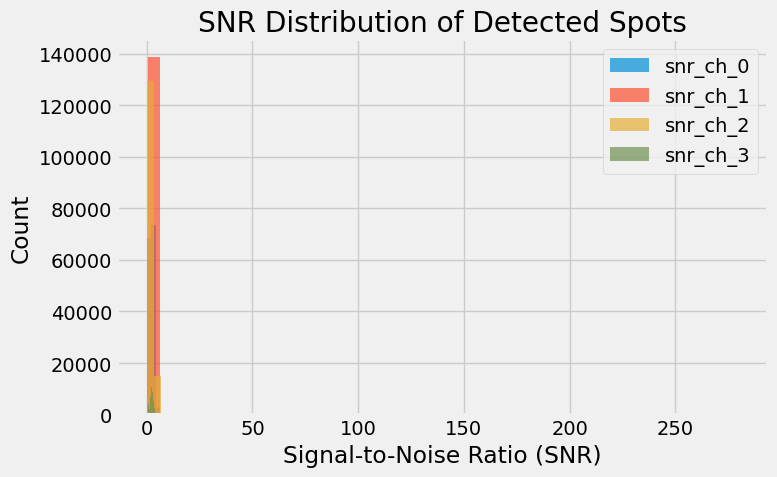


snr_ch_0:
  Mean SNR: 2.19
  Median SNR: 2.18
  Std SNR: 1.28

snr_ch_1:
  Mean SNR: 6.56
  Median SNR: 2.53
  Std SNR: 22.13

snr_ch_2:
  Mean SNR: 2.29
  Median SNR: 2.21
  Std SNR: 2.90

snr_ch_3:
  Mean SNR: 2.20
  Median SNR: 2.21
  Std SNR: 0.94


In [10]:
if not df_tracking.empty:
    # Find SNR column (named like 'snr_ch_1' for channel 1)
    snr_columns = [col for col in df_tracking.columns if 'snr' in col.lower()]
    
    if snr_columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        
        for snr_col in snr_columns:
            snr_values = df_tracking[snr_col].dropna()
            ax.hist(snr_values, bins=50, alpha=0.7, label=snr_col)
        
        ax.set_xlabel('Signal-to-Noise Ratio (SNR)')
        ax.set_ylabel('Count')
        ax.set_title('SNR Distribution of Detected Spots')
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        for snr_col in snr_columns:
            snr_values = df_tracking[snr_col].dropna()
            print(f"\n{snr_col}:")
            print(f"  Mean SNR: {snr_values.mean():.2f}")
            print(f"  Median SNR: {snr_values.median():.2f}")
            print(f"  Std SNR: {snr_values.std():.2f}")
    else:
        print("No SNR columns found in tracking dataframe.")
else:
    print("No tracking data available.")

## Spot Intensity Time Course

Plot the average spot intensity over time for each channel.

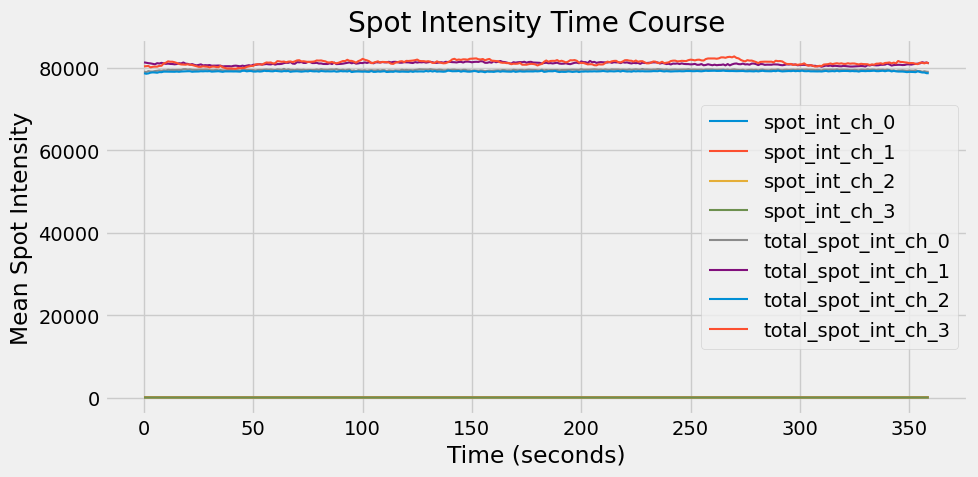

In [11]:
if not df_tracking.empty and 'frame' in df_tracking.columns:
    # Find intensity columns
    intensity_columns = [col for col in df_tracking.columns if 'spot_int' in col.lower()]
    
    if intensity_columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        
        time_axis = np.arange(df_tracking['frame'].max() + 1) * time_interval_sec
        
        for int_col in intensity_columns:
            # Calculate mean intensity per frame
            mean_intensity = df_tracking.groupby('frame')[int_col].mean()
            ax.plot(mean_intensity.index * time_interval_sec, mean_intensity.values, 
                   label=int_col, linewidth=1.5)
        
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('Mean Spot Intensity')
        ax.set_title('Spot Intensity Time Course')
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No intensity columns found in tracking dataframe.")
else:
    print("No tracking data available.")

## Particle Count Over Time

Plot the number of detected particles at each time point.

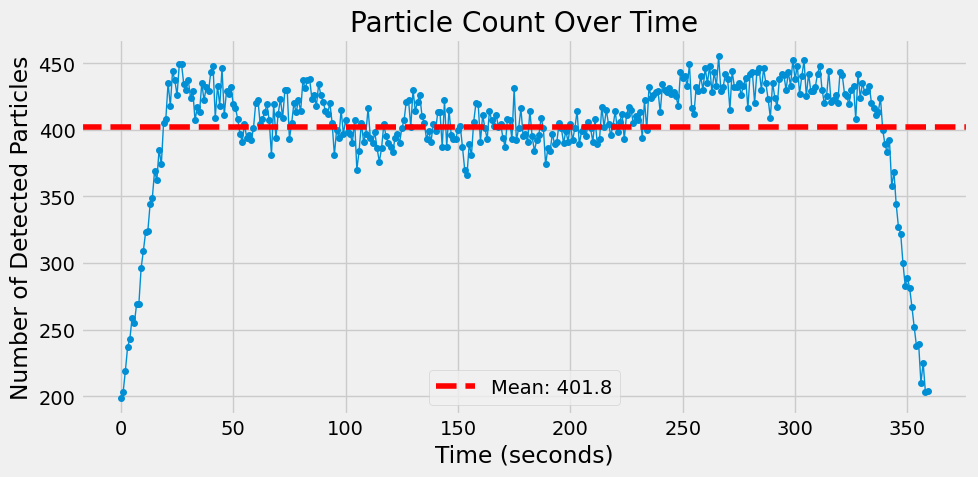

Average particles per frame: 401.8
Min: 199, Max: 455


In [12]:
if not df_tracking.empty and 'frame' in df_tracking.columns:
    # Count particles per frame
    particles_per_frame = df_tracking.groupby('frame').size()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(particles_per_frame.index * time_interval_sec, particles_per_frame.values, 
           'o-', markersize=4, linewidth=1)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Number of Detected Particles')
    ax.set_title('Particle Count Over Time')
    ax.axhline(particles_per_frame.mean(), color='red', linestyle='--', 
               label=f'Mean: {particles_per_frame.mean():.1f}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Average particles per frame: {particles_per_frame.mean():.1f}")
    print(f"Min: {particles_per_frame.min()}, Max: {particles_per_frame.max()}")
else:
    print("No tracking data available.")

## Export Results

Save all analysis results to CSV files for downstream processing.

In [13]:
# Create output directory
output_dir = Path("./results")
output_dir.mkdir(exist_ok=True)

# Export tracking data
if not df_tracking.empty:
    tracking_output = output_dir / "tracking_results.csv"
    df_tracking.to_csv(tracking_output, index=False)
    print(f"Tracking data saved to: {tracking_output}")

# Export segmentation mask
mask_output = output_dir / "segmentation_mask.tif"
tifffile.imwrite(str(mask_output), mask_cytosol.astype(np.uint16))
print(f"Segmentation mask saved to: {mask_output}")

# Export corrected image
corrected_output = output_dir / "corrected_image.tif"
tifffile.imwrite(str(corrected_output), image_corrected)
print(f"Corrected image saved to: {corrected_output}")

print("\n=== Analysis Complete ===")

Tracking data saved to: results/tracking_results.csv
Segmentation mask saved to: results/segmentation_mask.tif
Corrected image saved to: results/corrected_image.tif

=== Analysis Complete ===


## Batch Processing Example

Process multiple images in a loop. This demonstrates how MicroLive can be used for automated batch analysis.

In [14]:
# Example batch processing
# Uncomment and modify the code below for your batch analysis

'''
from glob import glob

# Find all TIFF files in a directory
image_files = sorted(glob("/path/to/images/*.tif"))

# Define axis order for your files
input_axis_order = ['T', 'C', 'Z', 'Y', 'X']  # Adjust to match your files

all_results = []

for image_path in image_files:
    print(f"\nProcessing: {Path(image_path).name}")
    
    # Load and convert image
    raw_image = tifffile.imread(image_path)
    converter = mi.ConvertFormat(
        image=raw_image,
        original_order=input_axis_order,
        desired_order=['T', 'Z', 'Y', 'X', 'C']
    )
    image_stack = converter.convert()
    
    # Run analysis pipeline
    # ... photobleaching, segmentation, tracking ...
    
    # Collect results
    if not df_tracking.empty:
        df_tracking['source_file'] = Path(image_path).name
        all_results.append(df_tracking)

# Combine all results
if all_results:
    combined_df = pd.concat(all_results, ignore_index=True)
    combined_df.to_csv("batch_results.csv", index=False)
    print(f"\nBatch processing complete. Total spots: {len(combined_df)}")
'''

print("Batch processing template ready. Uncomment and modify for your data.")

Batch processing template ready. Uncomment and modify for your data.
